<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_5/datasaurus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Helper Functions

In [2]:
def cohens_d(first_group, second_group):
    first_group = np.asarray(first_group)
    second_group = np.asarray(second_group)

    n_first = len(first_group)
    n_second = len(second_group)
    pooled_variance = (
        (n_first - 1) * first_group.var(ddof=1)
        + (n_second - 1) * second_group.var(ddof=1)
    ) / (n_first + n_second - 2)
    pooled_standard_deviation = np.sqrt(pooled_variance)

    return (first_group.mean() - second_group.mean()) / (
        pooled_standard_deviation
    )

In [3]:
def compare_stats(data, group1, group2):
    df1 = data[data["dataset"] == group1]
    df2 = data[data["dataset"] == group2]

    columns = pd.MultiIndex.from_tuples(
        [
            ("x", group1.capitalize()),
            ("x", group2.capitalize()),
            ("y", group1.capitalize()),
            ("y", group2.capitalize()),
        ]
    )

    comparison = pd.DataFrame(
        [
            [
                df1["x"].mean(),
                df2["x"].mean(),
                df1["y"].mean(),
                df2["y"].mean(),
            ],
            [
                df1["x"].median(),
                df2["x"].median(),
                df1["y"].median(),
                df2["y"].median(),
            ],
            [
                df1["x"].var(ddof=1),
                df2["x"].var(ddof=1),
                df1["y"].var(ddof=1),
                df2["y"].var(ddof=1),
            ],
            [
                df1["x"].std(ddof=1),
                df2["x"].std(ddof=1),
                df1["y"].std(ddof=1),
                df2["y"].std(ddof=1),
            ],
        ],
        index=["Média", "Mediana", "Variância", "Desvio-padrão"],
        columns=columns,
    )

    return comparison

In [4]:
def plot_pair(data, datasets):
    sns.set_theme(style="darkgrid", context="notebook")
    subset = data[data["dataset"].isin(datasets)]
    grid = sns.FacetGrid(
        subset,
        col="dataset",
        col_wrap=2,
        height=4,
        sharex=True,
        sharey=True,
    )
    grid.map_dataframe(
        sns.scatterplot,
        x="x",
        y="y",
        s=20,
        linewidth=0,
    )
    grid.set(xlim=(0, 100), ylim=(0, 100))
    grid.set_axis_labels("x", "y")
    grid.set_titles("{col_name}")
    plt.show()

### Datasaurus

In [5]:
datasaurus_url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "main/data/2020/2020-10-13/datasaurus.csv"
)

datasaurus_df = pd.read_csv(datasaurus_url)

In [6]:
datasaurus_df.shape

(1846, 3)

In [7]:
datasaurus_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 43.4 KB


In [8]:
datasaurus_df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [9]:
datasaurus_df["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

In [10]:
star = datasaurus_df.loc[
    datasaurus_df["dataset"] == "star",
    ["x", "y"],
]

dino = datasaurus_df.loc[
    datasaurus_df["dataset"] == "dino",
    ["x", "y"],
]

## Mean (Média Aritmética)

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

Onde:
*   $\bar{x}$ representa a sample mean (média amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\sum$ (Sigma) indica a sum (soma) dos values (valores).

In [11]:
print(f"Dino's mean: {dino['x'].mean():.3f}, {dino['y'].mean():.3f}")
print(f"Star's mean: {star['x'].mean():.3f}, {star['y'].mean():.3f}")

Dino's mean: 54.263, 47.832
Star's mean: 54.267, 47.840


## Median (Mediana)

Para um conjunto de dados ordenado $x_1, x_2, \dots, x_n$:

Se $n$ é ímpar:
$$ \text{Mediana} = x_{\frac{n+1}{2}} $$

Se $n$ é par:
$$ \text{Mediana} = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2} $$

Onde:
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x$ representa os values (valores) individuais ordenados em ordem crescente.

In [12]:
print(f"Dino's median: {dino['x'].median():.3f}, {dino['y'].median():.3f}")
print(f"Star's median: {star['x'].median():.3f}, {star['y'].median():.3f}")

Dino's mediana: 53.333, 46.026
Star's mean: 56.535, 50.111


## Variance (Variância)

$$ s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

Onde:
*   $s^2$ representa a sample variance (variância amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\bar{x}$ representa a sample mean (média amostral).
*   $\sum$ indica a sum (soma) das squared differences (diferenças ao quadrado).

In [13]:
print(f"Dino's variance: {dino['x'].var(ddof=1):.3f}, {dino['y'].var(ddof=1):.3f}")
print(f"Star's variance: {star['x'].var(ddof=1):.3f}, {star['y'].var(ddof=1):.3f}")

Dino's variance: 281.070, 725.516
Star's variance: 281.198, 725.240


## Standard Deviation (Desvio Padrão)

$$ s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $$

Onde:
*   $s$ representa a sample standard deviation (desvio padrão amostral).
*   $n$ é o número de observations (observações) no dataset (conjunto de dados).
*   $x_i$ representa cada value (valor) individual.
*   $\bar{x}$ representa a sample mean (média amostral).
*   $\sum$ indica a sum (soma) das squared differences (diferenças ao quadrado).

In [14]:
print(f"Dino's standard deviation: {dino['x'].std(ddof=1):.3f}, {dino['y'].std(ddof=1):.3f}")
print(f"Star's standard deviation: {star['x'].std(ddof=1):.3f}, {star['y'].std(ddof=1):.3f}")

Dino's desvio padrão: 16.765, 26.935
Star's desvio padrão: 16.769, 26.930


## Cohen’s d: o detector final?

Depois de tantas medidas quase iguais, poderíamos querer um único número simples e poderoso para decidir se há uma diferença relevante. Vamos experimentar Cohen’s d separadamente em `x` e em `y` e, por enquanto, tratá-lo como esse detector final.

$$ d = \frac{\bar{x}_1 - \bar{x}_2}{s_p} $$

Onde o pooled standard deviation (desvio padrão agrupado) ($s_p$) é calculado como:

$$ s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}} $$

Onde:
*   $d$ representa o Cohen's *d* (d de Cohen).
*   $\bar{x}_1$ e $\bar{x}_2$ são as sample means (médias amostrais) do grupo 1 e grupo 2, respectivamente.
*   $s_p$ é o pooled standard deviation (desvio padrão agrupado).
*   $s_1^2$ e $s_2^2$ são as sample variances (variâncias amostrais) do grupo 1 e grupo 2.
*   $n_1$ e $n_2$ são os sample sizes (tamanhos das amostras) do grupo 1 e grupo 2.

In [15]:
d_x = abs(cohens_d(dino["x"], star["x"]))
d_y = abs(cohens_d(dino["y"], star["y"]))

print(f"Cohen's d ('x'): {d_x:.4f}")
print(f"Cohen's d ('y'): {d_y:.4f}")

Cohens D ('x'): 0.0002
Cohens D ('y'): 0.0003


In [16]:
dino_star_comparison = compare_stats(datasaurus_df, "dino", "star")
display(dino_star_comparison.round(3))

x                 y         
                  Dino     Star     Dino     Star
Média           54.263   54.267   47.832   47.840
Mediana         53.333   56.535   46.026   50.111
Variância      281.070  281.198  725.516  725.240
Desvio-padrão   16.765   16.769   26.935   26.930

In [17]:
print(
    "Os resumos marginais e Cohen’s d parecem encerrar a questão. "
    "Agora vamos observar os pares (x, y)."
)

Os resumos marginais e Cohen’s d parecem encerrar a questão. Agora vamos observar os pares (x, y).


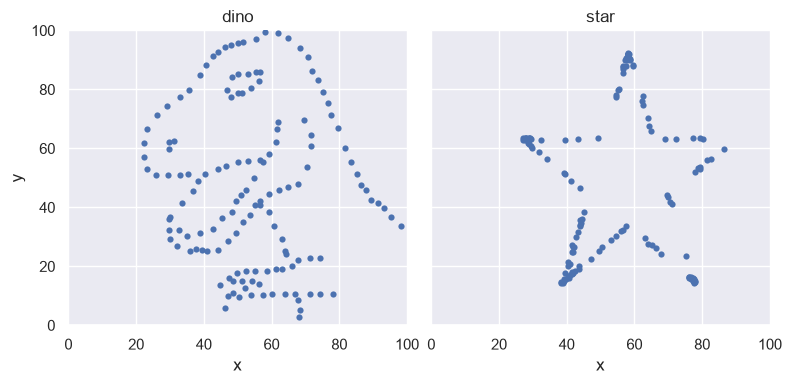

In [18]:
plot_pair(data=datasaurus_df, datasets=["dino", "star"])

### Debrief da armadilha

Cohen’s d não falhou. Ele mediu diferenças padronizadas entre as médias marginais, e essas médias são de fato quase iguais. Um valor `d ≈ 0` em `x` e em `y`, porém, não implica que dois datasets tenham a mesma estrutura conjunta.

A estatística respondeu corretamente a uma pergunta estreita, mas seria insuficiente para sustentar uma afirmação mais ampla sobre a forma dos pares `(x, y)`. Os scatterplots revelam estruturas radicalmente diferentes. Visualização é parte da análise, não decoração acrescentada depois da “estatística real”.

## Um segundo par para inspeção visual

In [19]:
bullseye = datasaurus_df.loc[
    datasaurus_df["dataset"] == "bullseye",
    ["x", "y"],
]

away = datasaurus_df.loc[
    datasaurus_df["dataset"] == "away",
    ["x", "y"],
]

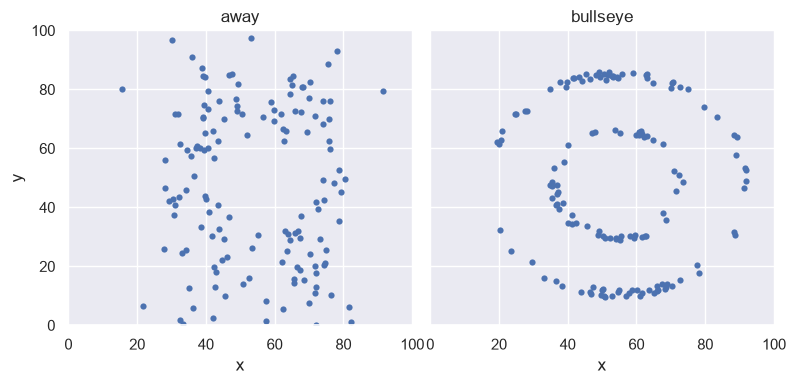

In [20]:
plot_pair(data=datasaurus_df, datasets=["bullseye", "away"])

### Para refletir

Que medida seria necessária se nossa pergunta fosse especificamente sobre agrupamentos, densidade local, dispersão radial ou forma geométrica?

A pergunta de pesquisa precisa definir qual aspecto da estrutura importa; não existe um escalar universal capaz de detectar toda diferença significativa.